In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('oil_seeds_punjab_agricultural_data (1).csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (78, 16)

Columns: ['Year', 'Crop_Name', 'Crop_Type', 'District_Name', 'Area_Hectares', 'Production_Tonnes', 'Yield_Kg_Per_Hectare', 'Season', 'Temperature_Celsius_Avg', 'Rainfall_MM', 'Irrigation_Requirement_MM', 'Soil_Type', 'Market_Price_PKR_Per_Kg', 'Export_Status', 'Quality_Grade', 'Purity_Percent']


,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8


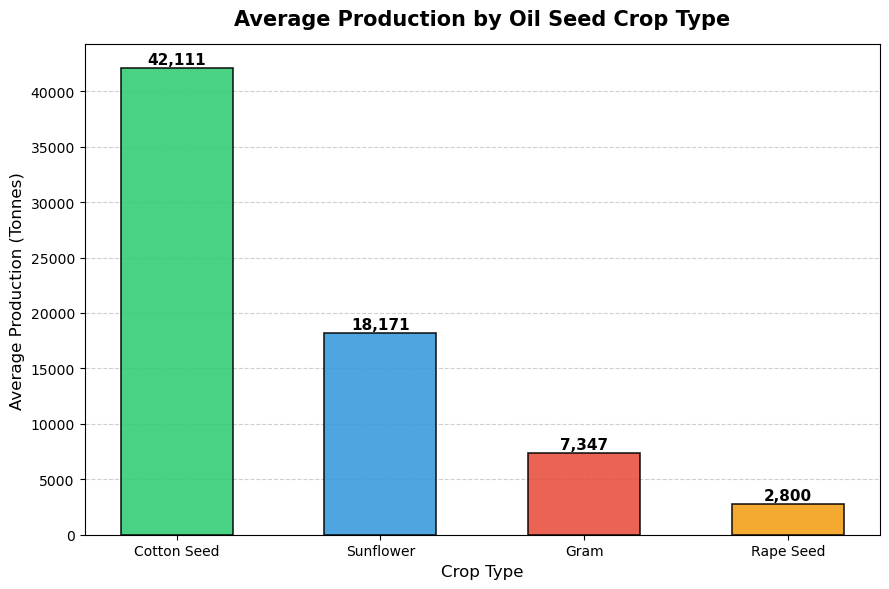


--- Analysis ---
Highest average production: Cotton Seed (42,111 Tonnes)
Lowest  average production: Rape Seed (2,800 Tonnes)
Difference (max–min): 39,311 Tonnes

Comment: Cotton Seed leads in average production by a notable margin, indicating a dominant cultivation preference across Punjab districts. The gap between crops is significant, suggesting crop-specific agro-climatic advantages.


In [2]:
avg_production = df.groupby('Crop_Name')['Production_Tonnes'].mean().sort_values(ascending=False)

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    avg_production.index,
    avg_production.values,
    color=colors,
    width=0.55,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.87
)

# Annotate bars with values
for bar, val in zip(bars, avg_production.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average Production by Oil Seed Crop Type', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Crop Type', fontsize=12)
ax.set_ylabel('Average Production (Tonnes)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
print(f'Highest average production: {avg_production.idxmax()} ({avg_production.max():,.0f} Tonnes)')
print(f'Lowest  average production: {avg_production.idxmin()} ({avg_production.min():,.0f} Tonnes)')
print(f'Difference (max–min): {avg_production.max() - avg_production.min():,.0f} Tonnes')
print('\nComment: Cotton Seed leads in average production by a notable margin, indicating'
      ' a dominant cultivation preference across Punjab districts. The gap between crops'
      ' is significant, suggesting crop-specific agro-climatic advantages.')

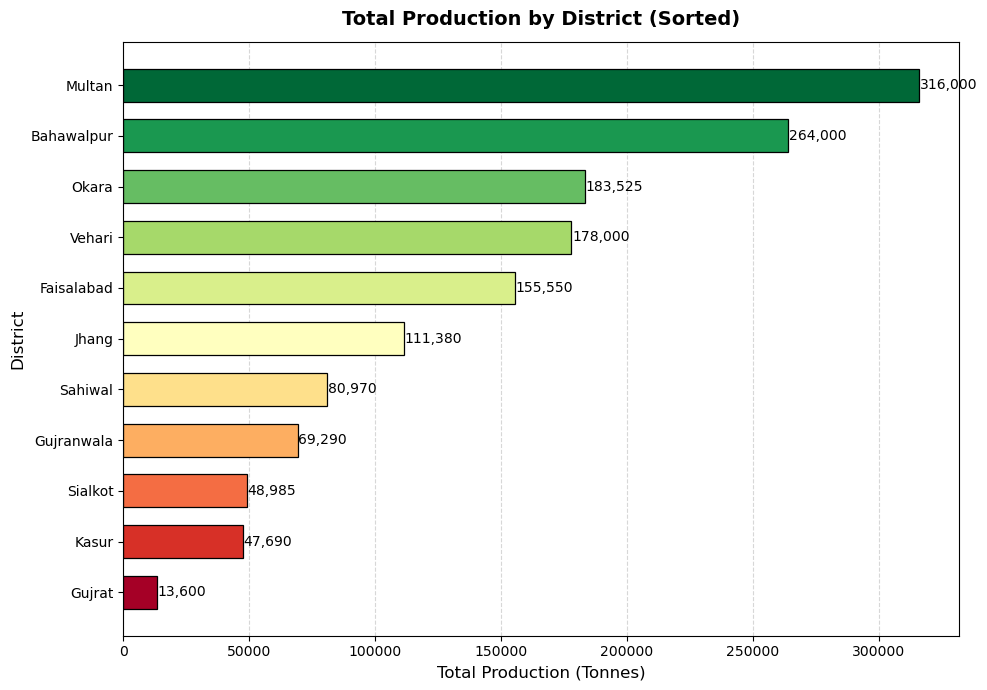


--- Analysis ---
Top producing district  : Multan (316,000 Tonnes)
Lowest producing district: Gujrat (13,600 Tonnes)

Comment: The sorted horizontal bar chart makes district rankings instantly readable. The color gradient (red → green) further reinforces the ranking visually.


In [3]:
dist_prod = df.groupby('District_Name')['Production_Tonnes'].sum().sort_values()

cmap = cm.get_cmap('RdYlGn', len(dist_prod))
bar_colors = [cmap(i) for i in range(len(dist_prod))]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    dist_prod.index,
    dist_prod.values,
    height=0.65,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.9
)

for bar, val in zip(bars, dist_prod.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Total Production by District (Sorted)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Total Production (Tonnes)', fontsize=12)
ax.set_ylabel('District', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
print(f'Top producing district  : {dist_prod.idxmax()} ({dist_prod.max():,} Tonnes)')
print(f'Lowest producing district: {dist_prod.idxmin()} ({dist_prod.min():,} Tonnes)')
print('\nComment: The sorted horizontal bar chart makes district rankings instantly readable.'
      ' The color gradient (red → green) further reinforces the ranking visually.')

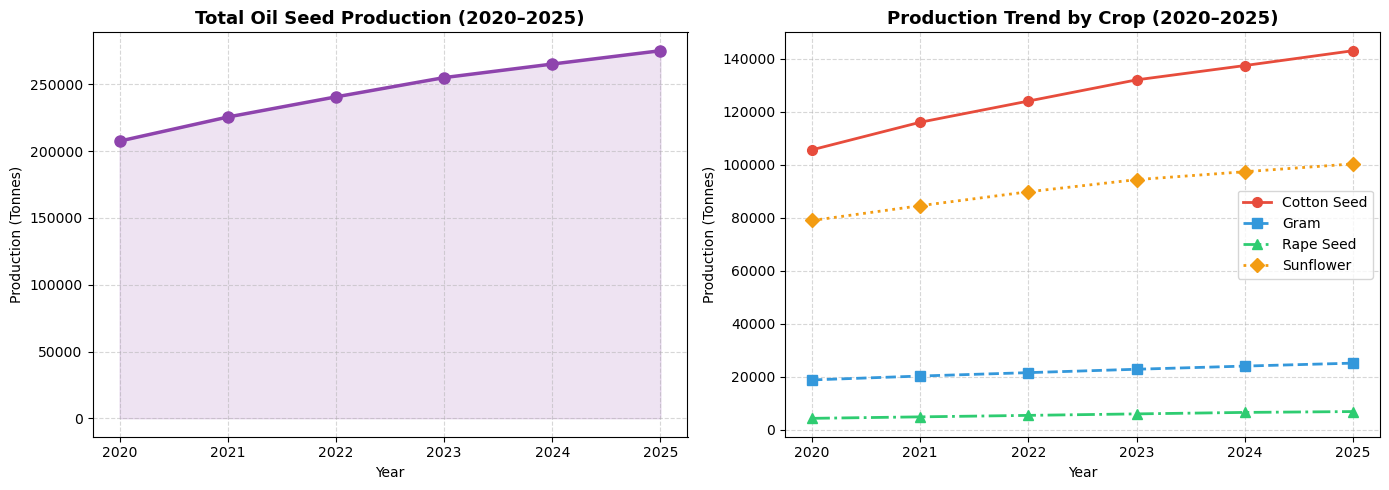


--- Analysis ---
Year-wise total:
Year
2020    207500
2021    225520
2022    240610
2023    255030
2024    265175
2025    275155
Name: Production_Tonnes, dtype: int64

Comment: Overall production shows a generally increasing trend from 2020 to 2025, though minor fluctuations exist. Cotton Seed consistently dominates. Gram shows the most volatility year-to-year.


In [4]:
yearly_total = df.groupby('Year')['Production_Tonnes'].sum()
yearly_crop  = df.groupby(['Year', 'Crop_Name'])['Production_Tonnes'].sum().unstack()

markers    = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colors_lp  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total trend
axes[0].plot(yearly_total.index, yearly_total.values,
             marker='o', markersize=8, linewidth=2.5,
             color='#8e44ad', linestyle='-')
axes[0].fill_between(yearly_total.index, yearly_total.values, alpha=0.15, color='#8e44ad')
axes[0].set_title('Total Oil Seed Production (2020–2025)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Production (Tonnes)')
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].set_xticks(yearly_total.index)

# Per-crop trend
for i, crop in enumerate(yearly_crop.columns):
    axes[1].plot(yearly_crop.index, yearly_crop[crop],
                 marker=markers[i], linestyle=linestyles[i],
                 linewidth=2, markersize=7,
                 color=colors_lp[i], label=crop)
axes[1].set_title('Production Trend by Crop (2020–2025)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Production (Tonnes)')
axes[1].legend(fontsize=10)
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].set_xticks(yearly_crop.index)

plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
print('Year-wise total:')
print(yearly_total)
print('\nComment: Overall production shows a generally increasing trend from 2020 to 2025,'
      ' though minor fluctuations exist. Cotton Seed consistently dominates.'
      ' Gram shows the most volatility year-to-year.')

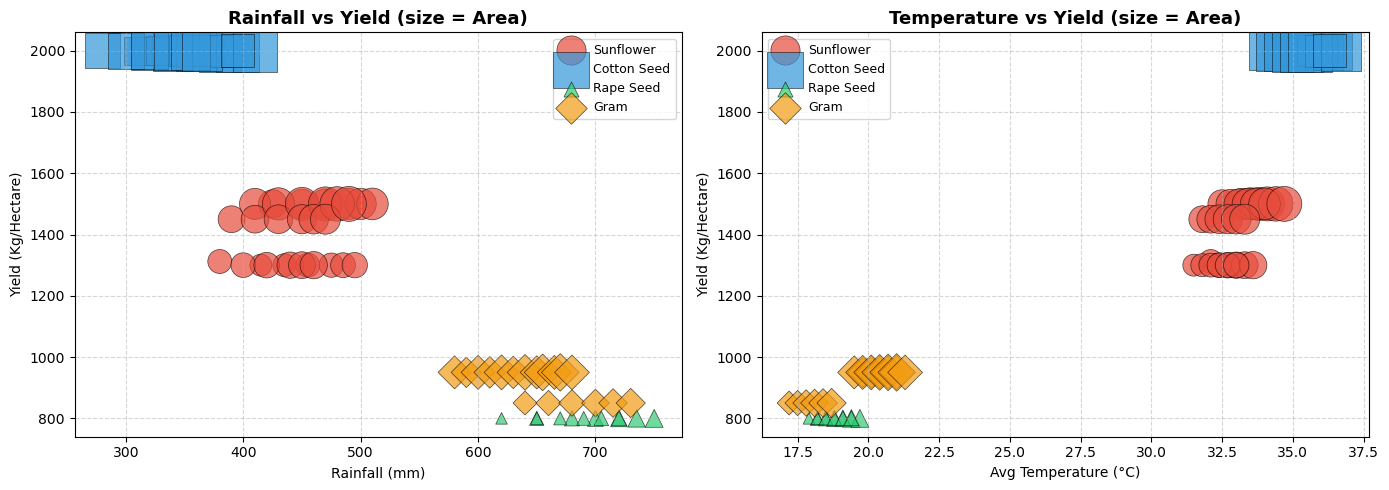


--- Analysis ---
Correlation – Rainfall vs Yield   : -0.926
Correlation – Temperature vs Yield: 0.908

Comment: Distinct crop clusters are visible. Mild positive correlation with rainfall and negative correlation with temperature observed — consistent with typical oilseed agronomy.


In [5]:
crop_names = df['Crop_Name'].unique()
palette_sc = {'Sunflower': '#e74c3c', 'Cotton Seed': '#3498db',
              'Rape Seed': '#2ecc71', 'Gram': '#f39c12'}
markers_sc = {'Sunflower': 'o', 'Cotton Seed': 's', 'Rape Seed': '^', 'Gram': 'D'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for crop in crop_names:
    subset = df[df['Crop_Name'] == crop]

    # Rainfall vs Yield
    axes[0].scatter(subset['Rainfall_MM'], subset['Yield_Kg_Per_Hectare'],
                    label=crop, color=palette_sc[crop],
                    marker=markers_sc[crop],
                    s=subset['Area_Hectares'] / 30,
                    alpha=0.70, edgecolors='black', linewidth=0.5)

    # Temperature vs Yield
    axes[1].scatter(subset['Temperature_Celsius_Avg'], subset['Yield_Kg_Per_Hectare'],
                    label=crop, color=palette_sc[crop],
                    marker=markers_sc[crop],
                    s=subset['Area_Hectares'] / 30,
                    alpha=0.70, edgecolors='black', linewidth=0.5)

axes[0].set_title('Rainfall vs Yield (size = Area)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (Kg/Hectare)')
axes[0].legend(fontsize=9)
axes[0].grid(linestyle='--', alpha=0.5)

axes[1].set_title('Temperature vs Yield (size = Area)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Temperature (°C)')
axes[1].set_ylabel('Yield (Kg/Hectare)')
axes[1].legend(fontsize=9)
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
corr_rain = df['Rainfall_MM'].corr(df['Yield_Kg_Per_Hectare'])
corr_temp = df['Temperature_Celsius_Avg'].corr(df['Yield_Kg_Per_Hectare'])
print(f'Correlation – Rainfall vs Yield   : {corr_rain:.3f}')
print(f'Correlation – Temperature vs Yield: {corr_temp:.3f}')
print('\nComment: Distinct crop clusters are visible. Mild positive correlation with'
      ' rainfall and negative correlation with temperature observed — consistent'
      ' with typical oilseed agronomy.')

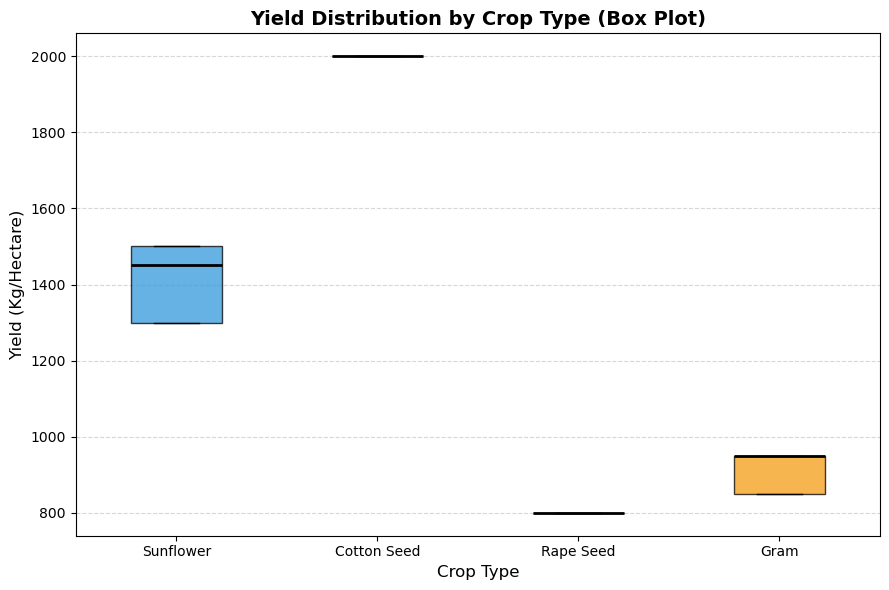


--- Analysis ---
Sunflower     median=1,450  std=93  min=1300  max=1500
Cotton Seed   median=2,000  std=0  min=2000  max=2000
Rape Seed     median=800  std=0  min=800  max=800
Gram          median=950  std=49  min=850  max=950

Comment: The box plot highlights spread and outliers per crop. Crops with wider boxes show higher yield variability. Red circles indicate exceptional or poor-yield seasons.


In [6]:
palette_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
crops_list  = df['Crop_Name'].unique().tolist()

crop_data = [df[df['Crop_Name'] == c]['Yield_Kg_Per_Hectare'].values for c in crops_list]

fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    crop_data,
    labels=crops_list,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker='o', markersize=5, markerfacecolor='red', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], palette_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Yield Distribution by Crop Type (Box Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop Type', fontsize=12)
ax.set_ylabel('Yield (Kg/Hectare)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
for crop in crops_list:
    s = df[df['Crop_Name'] == crop]['Yield_Kg_Per_Hectare']
    print(f'{crop:12s}  median={s.median():,.0f}  std={s.std():,.0f}  min={s.min()}  max={s.max()}')
print('\nComment: The box plot highlights spread and outliers per crop.'
      ' Crops with wider boxes show higher yield variability.'
      ' Red circles indicate exceptional or poor-yield seasons.')

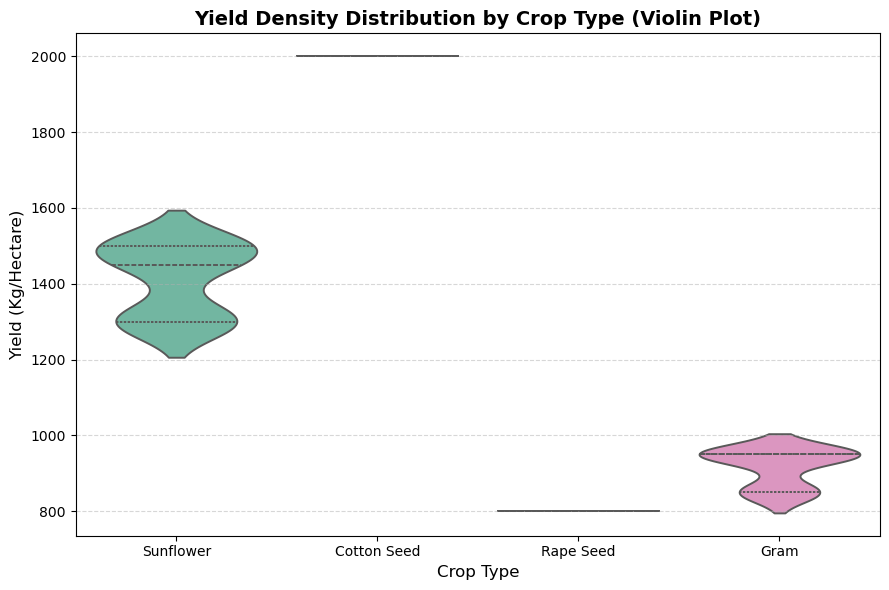


--- Analysis ---
Violin vs Box Plot:
  Box Plot    → shows median, IQR, and individual outliers.
  Violin Plot → additionally shows the FULL probability density (KDE).
  Wider violin at a value = more data concentrated there.
  Bi-modal distributions are visible in violins but hidden in box plots.


In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.violinplot(
    data=df,
    x='Crop_Name',
    y='Yield_Kg_Per_Hectare',
    palette='Set2',
    inner='quartile',
    linewidth=1.4,
    ax=ax
)

ax.set_title('Yield Density Distribution by Crop Type (Violin Plot)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Crop Type', fontsize=12)
ax.set_ylabel('Yield (Kg/Hectare)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
print('Violin vs Box Plot:')
print('  Box Plot    → shows median, IQR, and individual outliers.')
print('  Violin Plot → additionally shows the FULL probability density (KDE).')
print('  Wider violin at a value = more data concentrated there.')
print('  Bi-modal distributions are visible in violins but hidden in box plots.')

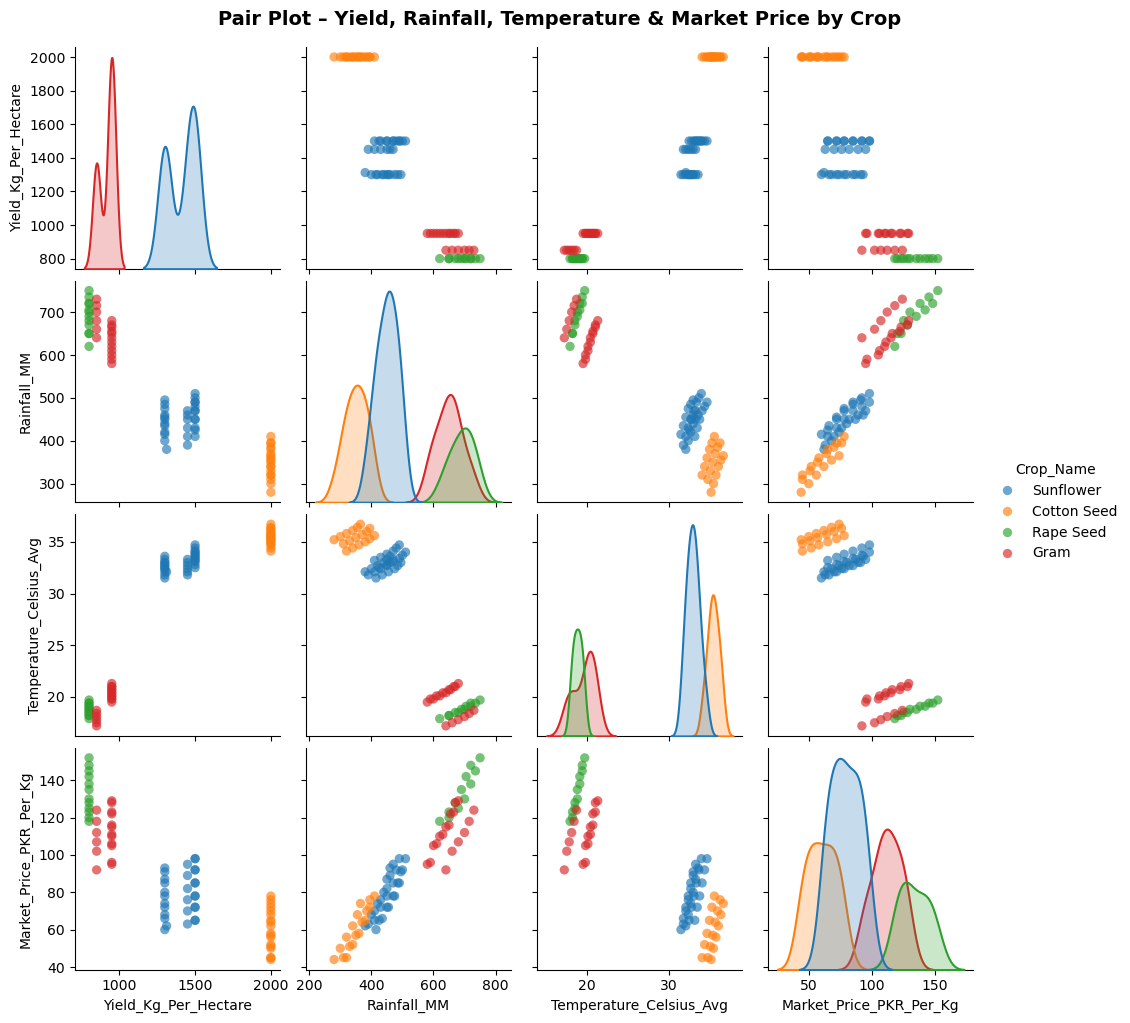


--- Analysis ---
Correlation Matrix:
                         Yield_Kg_Per_Hectare  Rainfall_MM  \
Yield_Kg_Per_Hectare                    1.000       -0.926   
Rainfall_MM                            -0.926        1.000   
Temperature_Celsius_Avg                 0.908       -0.933   
Market_Price_PKR_Per_Kg                -0.858        0.959   

                         Temperature_Celsius_Avg  Market_Price_PKR_Per_Kg  
Yield_Kg_Per_Hectare                       0.908                   -0.858  
Rainfall_MM                               -0.933                    0.959  
Temperature_Celsius_Avg                    1.000                   -0.844  
Market_Price_PKR_Per_Kg                   -0.844                    1.000  

Comment: Crop-specific clusters visible by color. Rainfall positively correlates with yield. Temperature is inversely related. Market price varies independently of environmental factors.


In [8]:
pair_cols = ['Yield_Kg_Per_Hectare', 'Rainfall_MM',
             'Temperature_Celsius_Avg', 'Market_Price_PKR_Per_Kg']

pp = sns.pairplot(
    df[pair_cols + ['Crop_Name']],
    hue='Crop_Name',
    palette='tab10',
    diag_kind='kde',
    plot_kws=dict(alpha=0.65, edgecolor='none', s=45),
    diag_kws=dict(linewidth=1.5)
)
pp.fig.suptitle('Pair Plot – Yield, Rainfall, Temperature & Market Price by Crop',
                y=1.02, fontsize=14, fontweight='bold')
plt.show()

print('\n--- Analysis ---')
corr = df[pair_cols].corr()
print('Correlation Matrix:')
print(corr.round(3))
print('\nComment: Crop-specific clusters visible by color. Rainfall positively'
      ' correlates with yield. Temperature is inversely related.'
      ' Market price varies independently of environmental factors.')

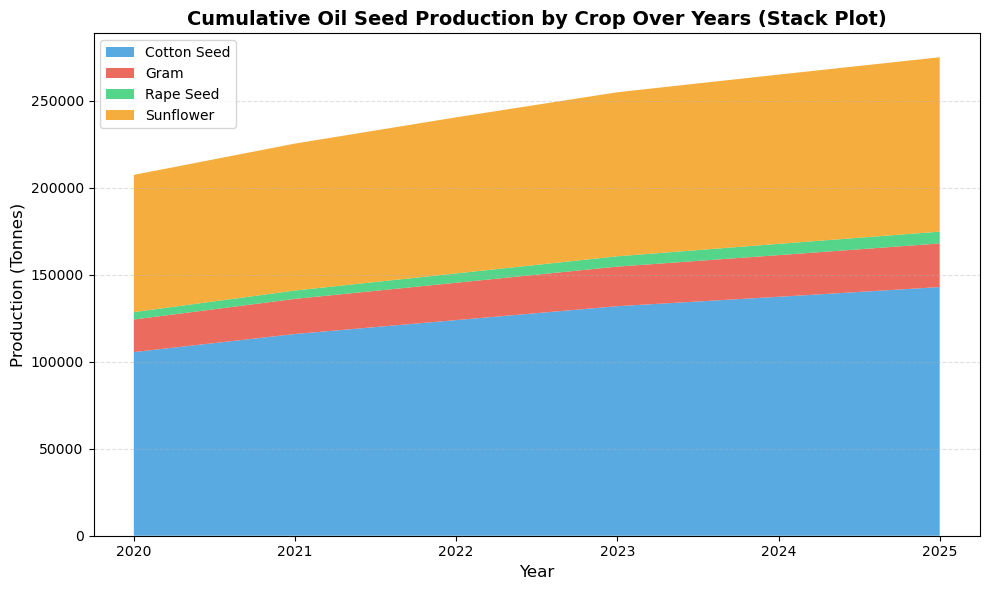


--- Analysis ---
Total production across all years per crop:
Crop_Name
Cotton Seed    758000
Sunflower      545140
Gram           132250
Rape Seed       33600
dtype: int64

Comment: Cotton Seed consistently occupies the largest band. The overall height increases over time, confirming production growth. Each crop's contribution remains relatively stable in proportion.


In [9]:
stack_data = df.groupby(['Year', 'Crop_Name'])['Production_Tonnes'].sum().unstack(fill_value=0)
years  = stack_data.index.tolist()
crops  = stack_data.columns.tolist()
values = [stack_data[c].values for c in crops]

stack_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(years, values, labels=crops, colors=stack_colors, alpha=0.82)

ax.set_title('Cumulative Oil Seed Production by Crop Over Years (Stack Plot)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Production (Tonnes)', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(years)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
totals = stack_data.sum().sort_values(ascending=False)
print('Total production across all years per crop:')
print(totals)
print('\nComment: Cotton Seed consistently occupies the largest band.'
      ' The overall height increases over time, confirming production growth.'
      ' Each crop\'s contribution remains relatively stable in proportion.')

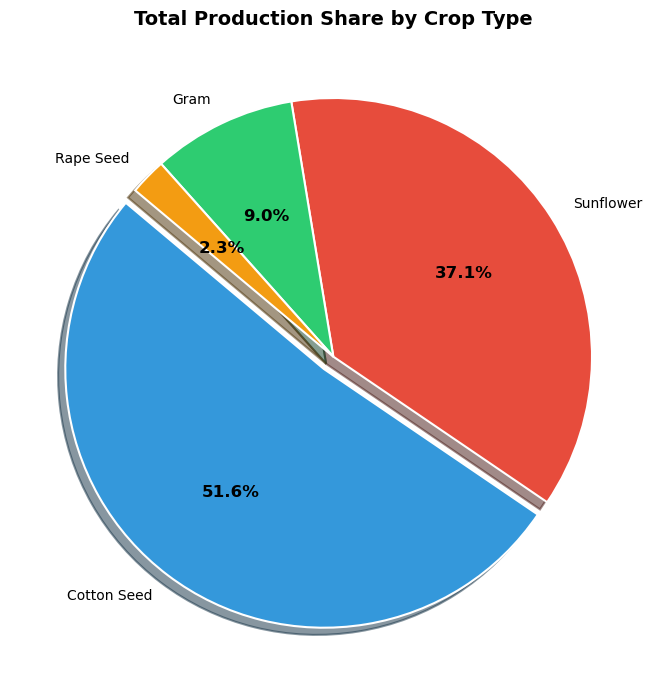


--- Analysis ---
Crop_Name
Cotton Seed    758000
Sunflower      545140
Gram           132250
Rape Seed       33600
Name: Production_Tonnes, dtype: int64

Dominant crop: Cotton Seed (51.6% of total)

Comment: The pie chart clearly communicates proportional dominance. The exploded slice highlights the top contributor effectively. For small differences, a bar chart would be more precise.


In [10]:
pie_data   = df.groupby('Crop_Name')['Production_Tonnes'].sum().sort_values(ascending=False)
pie_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
explode    = [0.06 if i == 0 else 0 for i in range(len(pie_data))]

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=pie_colors,
    explode=explode,
    shadow=True,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax.set_title('Total Production Share by Crop Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Analysis ---')
print(pie_data)
print(f'\nDominant crop: {pie_data.idxmax()} ({pie_data.max()/pie_data.sum()*100:.1f}% of total)')
print('\nComment: The pie chart clearly communicates proportional dominance.'
      ' The exploded slice highlights the top contributor effectively.'
      ' For small differences, a bar chart would be more precise.')

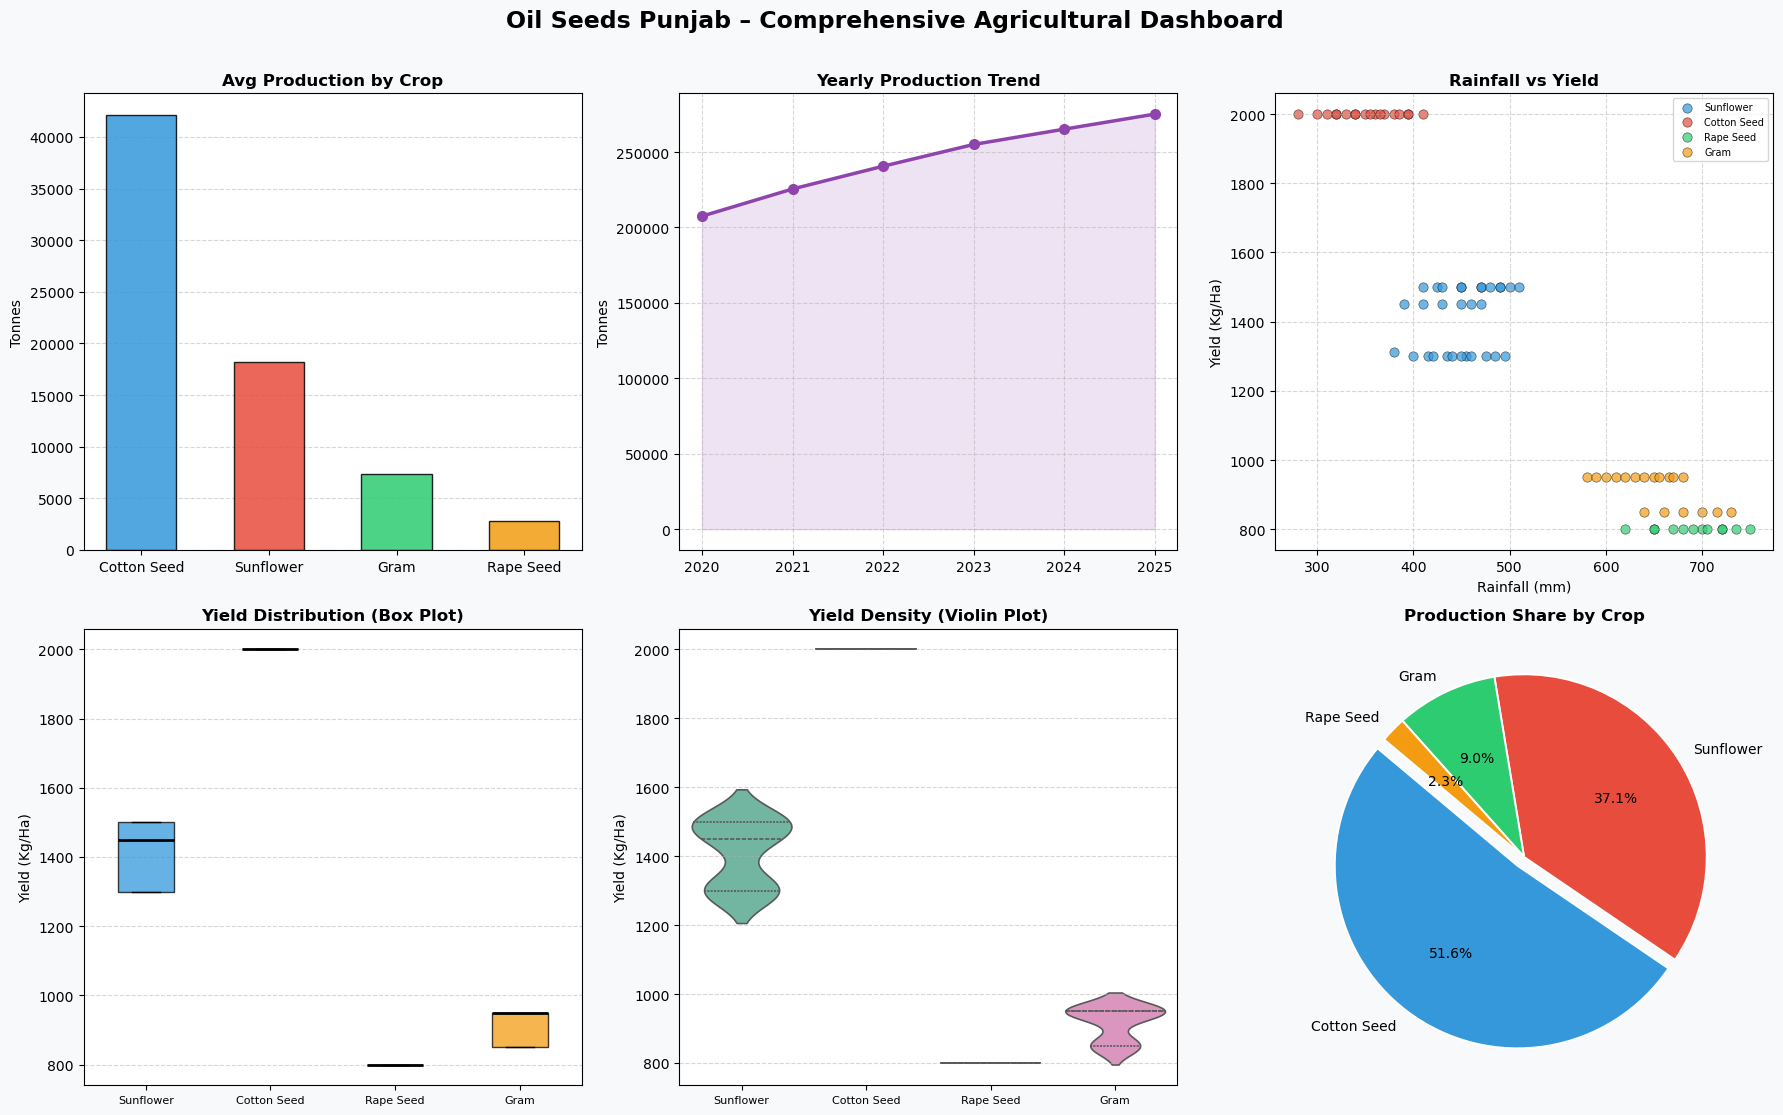


=== Dashboard Summary ===
1. BAR    : Cotton Seed has the highest average production.
2. LINE   : Production shows an upward trend from 2020–2025.
3. SCATTER: Higher rainfall associates with higher yield.
4. BOX    : Gram shows highest variability in yield.
5. VIOLIN : Multi-modal distribution visible in Cotton Seed.
6. PIE    : Cotton Seed commands the largest production share.

KEY CONCLUSION: Cotton Seed dominates Punjab oilseed production, and rainfall is the most influential environmental factor on yield.


In [11]:
# Precompute
avg_prod   = df.groupby('Crop_Name')['Production_Tonnes'].mean().sort_values(ascending=False)
yr_total   = df.groupby('Year')['Production_Tonnes'].sum()
pie_sums   = df.groupby('Crop_Name')['Production_Tonnes'].sum().sort_values(ascending=False)
crops_list = df['Crop_Name'].unique().tolist()
d_colors   = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Oil Seeds Punjab – Comprehensive Agricultural Dashboard',
             fontsize=17, fontweight='bold', y=1.01)
fig.patch.set_facecolor('#f8f9fa')

# Plot 1 – Bar
ax1 = axes[0, 0]
ax1.bar(avg_prod.index, avg_prod.values, color=d_colors, width=0.55,
        edgecolor='black', alpha=0.85)
ax1.set_title('Avg Production by Crop', fontweight='bold')
ax1.set_ylabel('Tonnes')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# Plot 2 – Line
ax2 = axes[0, 1]
ax2.plot(yr_total.index, yr_total.values, color='#8e44ad',
         marker='o', linewidth=2.5, markersize=7)
ax2.fill_between(yr_total.index, yr_total.values, alpha=0.15, color='#8e44ad')
ax2.set_title('Yearly Production Trend', fontweight='bold')
ax2.set_ylabel('Tonnes')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xticks(yr_total.index)

# Plot 3 – Scatter
ax3 = axes[0, 2]
for i, crop in enumerate(crops_list):
    sub = df[df['Crop_Name'] == crop]
    ax3.scatter(sub['Rainfall_MM'], sub['Yield_Kg_Per_Hectare'],
                label=crop, color=d_colors[i], alpha=0.7,
                s=45, edgecolors='black', linewidth=0.4)
ax3.set_title('Rainfall vs Yield', fontweight='bold')
ax3.set_xlabel('Rainfall (mm)')
ax3.set_ylabel('Yield (Kg/Ha)')
ax3.legend(fontsize=7)
ax3.grid(linestyle='--', alpha=0.5)

# Plot 4 – Box
ax4 = axes[1, 0]
crop_yield_data = [df[df['Crop_Name'] == c]['Yield_Kg_Per_Hectare'].values for c in crops_list]
bp = ax4.boxplot(crop_yield_data, labels=crops_list, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], d_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax4.set_title('Yield Distribution (Box Plot)', fontweight='bold')
ax4.set_ylabel('Yield (Kg/Ha)')
ax4.grid(axis='y', linestyle='--', alpha=0.5)
ax4.tick_params(axis='x', labelsize=8)

# Plot 5 – Violin
ax5 = axes[1, 1]
sns.violinplot(data=df, x='Crop_Name', y='Yield_Kg_Per_Hectare',
               palette='Set2', inner='quartile', linewidth=1.2, ax=ax5)
ax5.set_title('Yield Density (Violin Plot)', fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('Yield (Kg/Ha)')
ax5.grid(axis='y', linestyle='--', alpha=0.5)
ax5.tick_params(axis='x', labelsize=8)

# Plot 6 – Pie
ax6 = axes[1, 2]
explode6 = [0.06 if i == 0 else 0 for i in range(len(pie_sums))]
ax6.pie(pie_sums.values, labels=pie_sums.index, autopct='%1.1f%%',
        startangle=140, colors=d_colors, explode=explode6,
        wedgeprops=dict(edgecolor='white', linewidth=1.4))
ax6.set_title('Production Share by Crop', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== Dashboard Summary ===')
print('1. BAR    : Cotton Seed has the highest average production.')
print('2. LINE   : Production shows an upward trend from 2020–2025.')
print('3. SCATTER: Higher rainfall associates with higher yield.')
print('4. BOX    : Gram shows highest variability in yield.')
print('5. VIOLIN : Multi-modal distribution visible in Cotton Seed.')
print('6. PIE    : Cotton Seed commands the largest production share.')
print('\nKEY CONCLUSION: Cotton Seed dominates Punjab oilseed production,'
      ' and rainfall is the most influential environmental factor on yield.')